# 05: SVR (Linear Kernel) Training

- Primary model: **Support Vector Regression (SVR)** with a **linear kernel**
- Cross-validation: standard **KFold** and **TimeSeriesSplit**
- Hyperparameter tuning: exhaustive **GridSearchCV** using **TimeSeriesSplit**


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from utils import (
    load_data, 
    train_test_split, 
    visualize_predictions, 
    visualize_feature_importance, 
    train_test_model, 
    visualize_prediction_vs_actual, 
    time_series_grid_search
)


sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 200)


In [2]:
df, feature_cols,target_col =  load_data()
X_train, y_train, X_test, y_test = train_test_split(df, feature_cols, target_col)

Configured target: target_close_1d
Configured features: ['rsi_14', 'macd_hist_12_26_9', 'bb_bandwidth_20_2', 'adx_14', 'obv', 'adj_close_smooth', 'ema_20', 'atr_14', 'volume']
Train rows: 1984
Test rows:  495
Train period: 2016-06-03 -> 2024-04-22
Test period:  2024-04-23 -> 2026-04-14


In [3]:
svr_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("svr", SVR(kernel="linear", C=1.0, epsilon=0.1)),
    ]
)

pred_train, pred_test, model = train_test_model(svr_model, X_train, y_train, X_test, y_test, save_json=True, model_name="SVR-linear_(baseline)")

                           Model    MAE    RMSE    MAPE      R2
0  SVR-linear_(baseline)_(train)  1.751  2.6564  0.0186  0.9978
                          Model     MAE   RMSE    MAPE      R2
0  SVR-linear_(baseline)_(test)  4.3315  5.972  0.0191  0.9477


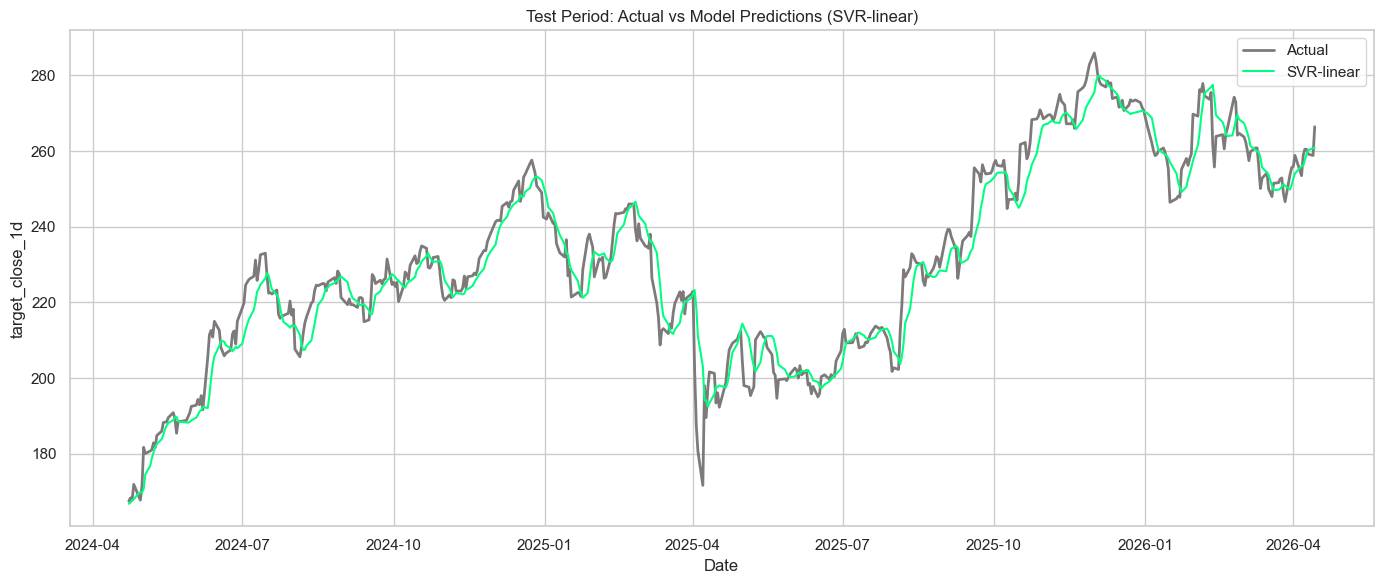

In [4]:
visualize_prediction_vs_actual(y_test, pred_test, target_col, "SVR-linear")

## Exhaustive Grid Search (Hyperparameter Tuning)


**SVR (Grid Search with TimeSeriesSplit):**  
An exhaustive `GridSearchCV` is run **only on the training set**, using `TimeSeriesSplit(n_splits=5)` to validate **forward-in-time** (train on earlier data, test on later data) and avoid leakage. The best SVR configuration is selected by **minimizing RMSE** (`scoring="neg_root_mean_squared_error"`).


The hyperparameters tuned are:
- `svr__C`: **regularization/penalty strength** (higher `C` fits training data more tightly; lower `C` is more regularized/smoother).
- `svr__epsilon`: **epsilon-insensitive tube width** (larger `epsilon` ignores small errors → smoother, fewer support vectors; smaller `epsilon` fits more closely).
- `svr__gamma`: **RBF kernel sensitivity** (higher `gamma` makes the model more local/complex; lower `gamma` makes it smoother and more global).

In [5]:
svr_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("svr", SVR(kernel="linear")),
    ]
)

# Exhaustive hyperparameter tuning with TimeSeriesSplit
param_grid = {
    "svr__C": np.logspace(-2, 3, 6),
    "svr__epsilon": np.logspace(-6, 0, 5),
    "svr__gamma": np.logspace(-6, 2, 5),
}

best_estimator, best_pred_test = time_series_grid_search(
    svr_model, param_grid, X_train, y_train, X_test, y_test, save_json=True, model_name="SVR-linear_(tuned)"
)


Fitting 5 folds for each of 150 candidates, totalling 750 fits
Best params: {'svr__C': np.float64(10.0), 'svr__epsilon': np.float64(0.03162277660168379), 'svr__gamma': np.float64(1e-06)}
                                Model     MAE    RMSE    MAPE      R2
0  SVR-linear_(tuned)_(tuned)_(train)  1.6142  2.4695  0.0165  0.9981
                               Model     MAE    RMSE    MAPE      R2
0  SVR-linear_(tuned)_(tuned)_(test)  3.9648  5.4393  0.0175  0.9566


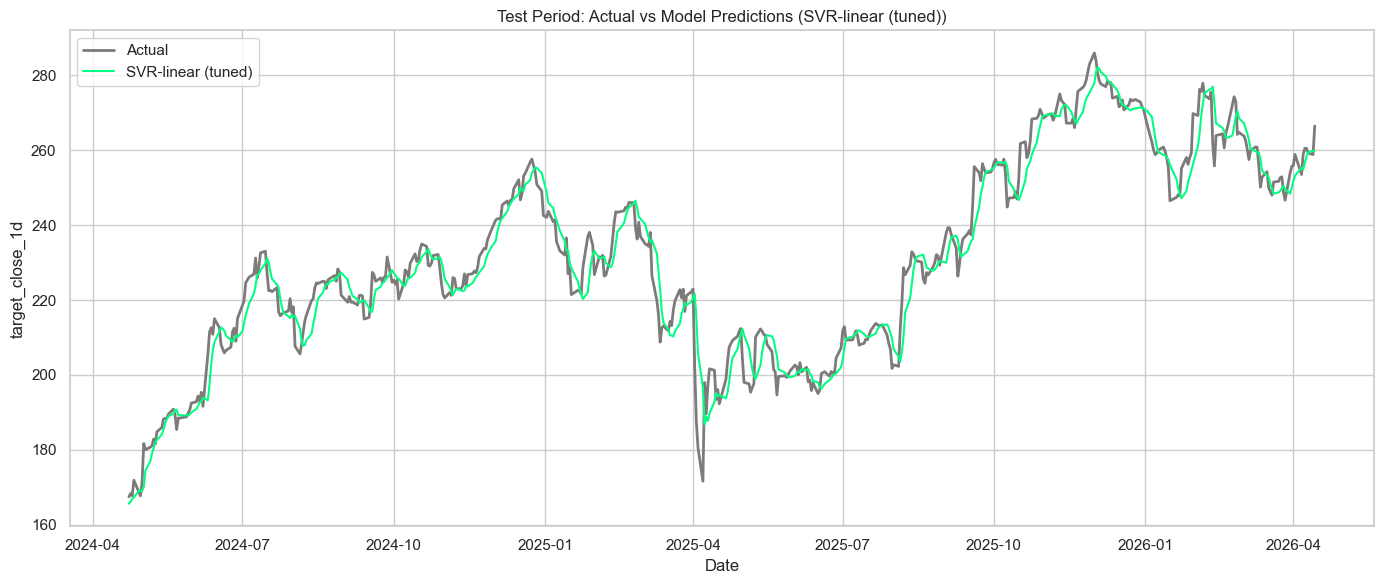

In [9]:
visualize_prediction_vs_actual(y_test, best_pred_test, target_col, "SVR-linear (tuned)")

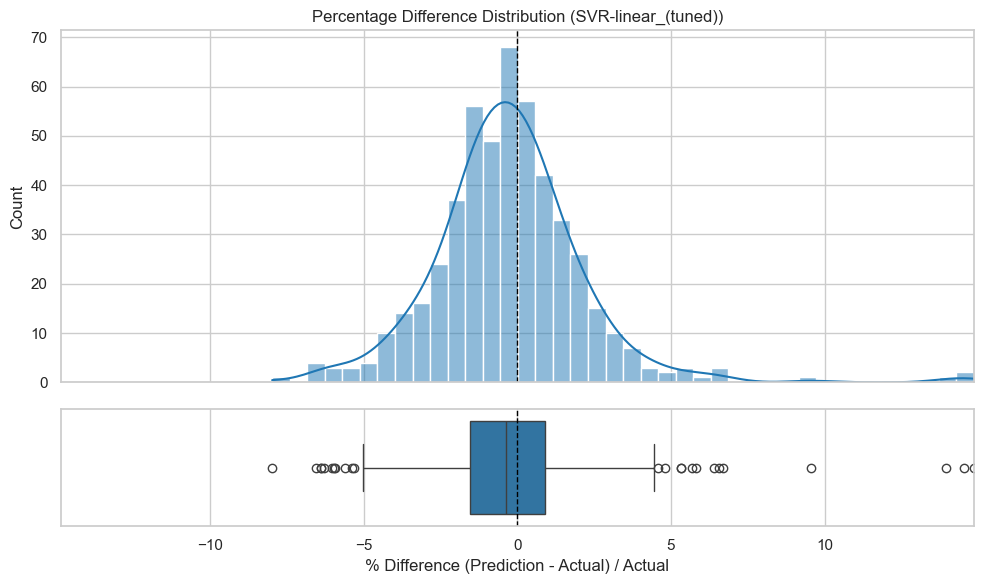

In [7]:
visualize_predictions(y_test, best_pred_test, "SVR-linear_(tuned)", save_json=True)

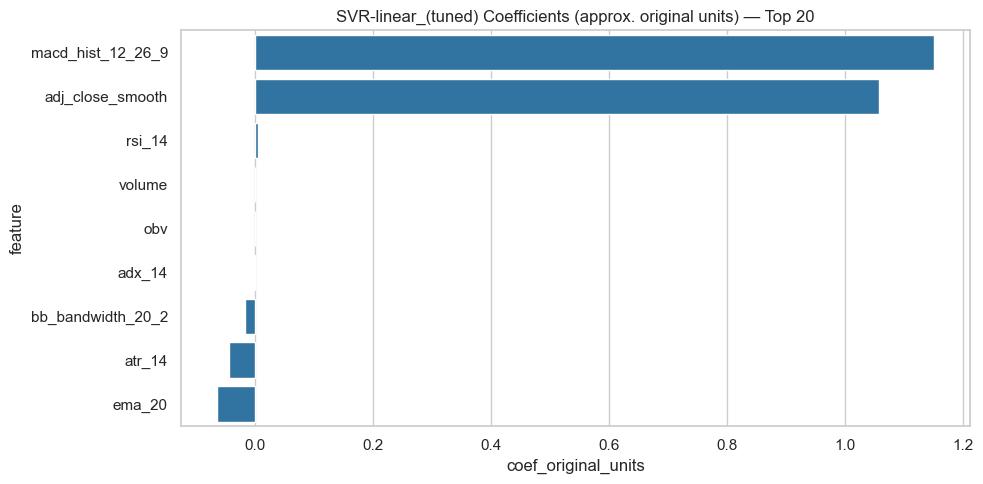

,feature,coef_scaled,coef_original_units
0,macd_hist_12_26_9,0.648999,1.150369e+00
1,adj_close_smooth,59.591574,1.057147e+00
2,rsi_14,0.129960,5.230327e-03
3,volume,0.146826,3.317290e-09
4,obv,0.510448,3.797382e-11
5,adx_14,-0.009174,-5.265138e-04
6,bb_bandwidth_20_2,-0.078686,-1.579059e-02
7,atr_14,-0.044963,-4.331507e-02
8,ema_20,-3.585575,-6.376095e-02


In [8]:
# Coefficients (linear kernel)
scaler = best_estimator.named_steps["scaler"]
svr = best_estimator.named_steps["svr"]

visualize_feature_importance(svr, scaler, feature_cols, "SVR-linear_(tuned)", save_json=True)